In [316]:
from numba import jit, njit
import kwant
from kwant.digest import uniform    # a (deterministic) pseudorandom number generator
import kwant.kpm


import scipy

import numpy as np
import matplotlib.pyplot as plt
from types import SimpleNamespace

import cmath

from qutip import *
from joblib import Parallel, delayed


In [317]:
def corr_dis(L, W, a, xic):
    Nx = int(L/a)
    Ny = int(W/a)
    Vxy = np.random.normal(0, 1., size=(Ny, Nx))/(a) + 1j*0.0
    
    kkVxy = np.fft.fft2(Vxy)
    kx = 2*np.pi * np.fft.fftfreq(kkVxy.shape[1],d=a)
    ky = 2*np.pi * np.fft.fftfreq(kkVxy.shape[0],d=a)
    kx, ky = np.meshgrid(kx,ky)
    
    kVxy = np.multiply(kkVxy, np.exp( - .125 * xic**2. * (kx**2.+ky**2.)  ) ) * xic/np.sqrt(2.)
    
    Vxy = np.fft.ifft2(kVxy)
    Vxy = Vxy - np.sum(Vxy)/(1.*Nx*Ny)

    return Vxy

In [318]:
def v_img_singleside(W, N, min_l):
    arr_x = np.linspace(min_l, W+min_l, N)
    arr_V = - 1./(np.abs( arr_x ))
    return arr_V


def v_img(W, N, min_l):
    arr_V = []
    arr_x = np.linspace(-W/2, W/2, N)
    d = 1000*W + 2*min_l
    for x in arr_x:
        V = 0
        nf = 50000
        n_Z = np.linspace( -nf, nf, 2*nf+1)
        for n in n_Z:
            if n != 0:
                V += ( 1./(2*np.abs(n)) - 1./(2.*np.abs(n+500*(x)/d )) )
        if x < 0:
            arr_V.append(V)
        else:
            arr_V.append(V)
    return np.asarray(arr_V)/d*1000


def v_expcutoff_img_singleside(W, N, min_l, xiV):
    arr_x = np.linspace(min_l, W+min_l, N)
    arr_V = - 1./(np.abs( arr_x ))*np.exp( -(arr_x-min_l)**2/(2*xiV**2) )
    #arr_V = - 1./(np.abs( arr_x )) /( np.exp( (arr_x-min_l - xiV)/(.01*xiV) ) + 1 )
    return arr_V

In [333]:
lat = kwant.lattice.square(a=1, norbs=2)

Ncore = 5       #number of cores used in the calculation
iter_dis = 1

t = 1   # hopping rate for kwant
W = 200  # spatial width of the system ( Nx )
L = 60  # spatial length of the system ( Ny )

# Energy-Length-Magnetic scale (arbitrary) just to have a dimensional reference for the parameters
#a=0.6 # real lattice spacing in GaAs, in nm
#BandW0 = 40   #total bandwidth in meV
#l0 = np.sqrt(568/BandW0*8.) * 10**(-3.) # effective lattice spacing sqrt( \hbar^2/(2m*)/(\hbar J)) here I took \hbar^2/(2m*) = 568 nm^2 meV (GaAs) and \hbar J = BW/8 in micron!
#B0 = 4.14*10**3. / (l0 * 10**3.)**2. #in T, as 2\pi \hbar/e 1/a^2

# Adimensional magnetic flux
alpha = 1./60.
lB = 1./np.sqrt(2*np.pi*alpha)
omB = 4*np.pi*alpha

# Define parameters
#g_factor = 2  # Effective g-factor (depends on material)
#mu_B = 5.788e-2  # Bohr magneton (meV/T)
#B_field = 1.0  # Magnetic field in Tesla (adjustable)
#Zeeman = g_factor * mu_B * B_field  # Zeeman splitting energy
Zeeman = omB/5

xic = lB * .75      # Correlation length and definition of disorder-potential array
Vdis = corr_dis(int(L), int(W), 1, xic)

plate_distance = 10*lB      #edge-plate distance

#Vimg = np.linspace(0, W-1, W)/lB
#E_img = omB * .4         #Image charge amplitude in cyclotrons
Vimg0 = v_img_singleside(W, int(W), plate_distance)   # normalized image potential single plate
Vimg1 = v_expcutoff_img_singleside(W, int(W), plate_distance, 12*lB)
Vimg = Vimg1
V_img_min = np.amin(Vimg)

Vimg = Vimg - V_img_min - lB/plate_distance**2 

E_img = omB*lB * 6         # Image charge amplitude in cyclotrons
#E_img = Zeeman*lB * ( (plate_distance/lB)**2 )/2. * 2         # Image charge amplitude in Zeeman

E_dis = omB * .02                   # disorder amplitude in cyclotrons


# Define Pauli matrices
sigma_0 = np.array([[1, 0], [0, 1]])  # Identity (spin-independent)
sigma_x = np.array([[0, 1], [1, 0]])  # Pauli X
sigma_y = np.array([[0, -1j], [1j, 0]])  # Pauli Y
sigma_z = np.array([[1, 0], [0, -1]])  # Zeeman term


def onsite(site, params):
    xi, yi = site.pos

    om0 = 4 * t * sigma_0  # Original onsite energy
    omRan = params.E_dis * params.V[int(yi)][int(xi)] * sigma_0  # Disorder
    omImg = params.E_img * Vimg[int(yi)] * sigma_0  # Image charge

    H_Zeeman = Zeeman / 2 * sigma_z  # Zeeman term (splits spin up/down)

    return om0 + omRan + omImg + H_Zeeman  # Return as a 2x2 matrix

def hopping(site_i, site_j, params):
    xi, yi = site_i.pos
    xj, yj = site_j.pos

    phase = -1j * 2 * np.pi * params.alpha * (xi - xj) * (yi + yj) / 2.
    
    return -t * np.exp(phase) * sigma_0  # Spin-preserving hopping

def onsite_lead(site, params):
    return 4 * t * sigma_0 + (Zeeman / 2) * sigma_z  # Zeeman in leads

def hopping_lead(site_i, site_j, params):
    return -t * sigma_0  # Spin-independent hopping

sys = kwant.Builder()
sys[(lat(x, y) for x in range(L) for y in range(W))] = onsite
sys[lat.neighbors()] = hopping

sym_left_lead = kwant.TranslationalSymmetry((-1, 0))
left_lead = kwant.Builder(sym_left_lead)
left_lead[(lat(0, y) for y in range(W))] = onsite_lead
left_lead[lat.neighbors()] = hopping_lead
sys.attach_lead(left_lead)
sys.attach_lead(left_lead.reversed())

sys = sys.finalized()

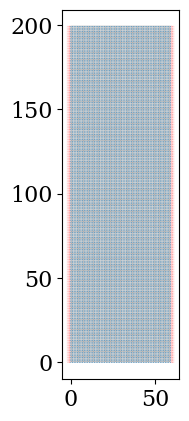

Text(0, 0.5, '$U_{\\rm img}/(\\hbar\\omega_B)$')

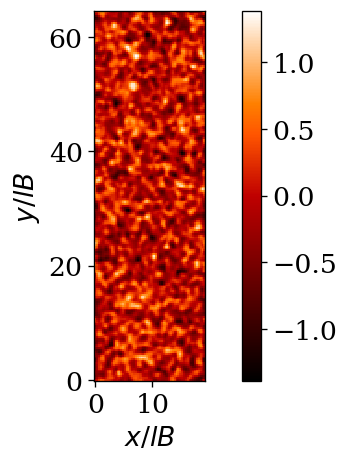

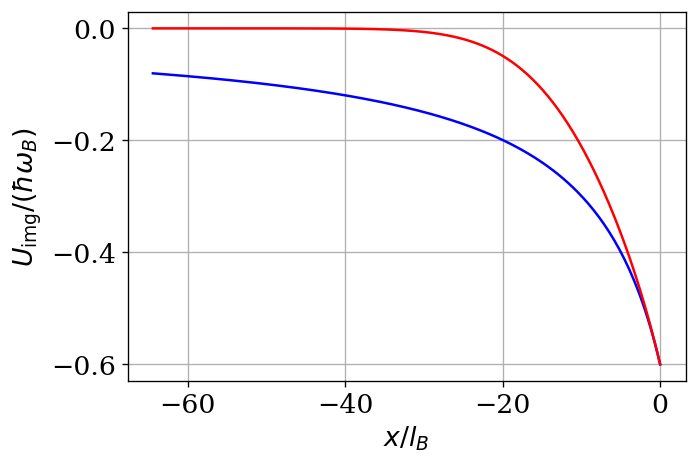

In [334]:
#plot some structural kwant stuff
kwant.plot(sys);

xvec = np.linspace(0, L-1, int(L) )
yvec = np.linspace(0, W-1, int(W) )
X, Y = np.meshgrid(xvec, yvec)

fig_W, ax_W = plt.subplots(dpi=120, figsize=(8, 4))
vmin = 0.
vmax = 1.000
Wmap_plot = ax_W.pcolormesh(X/lB, Y/lB, (Vdis.real), cmap='gist_heat', alpha=1)  #, vmin=vmin, vmax=vmax)
fig_W.colorbar(Wmap_plot)
ax_W.set_xlabel(r'$x/lB$')
ax_W.set_ylabel(r'$y/lB$')
ax_W.set_aspect('equal')


fig_Img, ax_Img = plt.subplots(dpi=120, figsize=(6, 4))
ssss = 1
ax_Img.plot( -yvec/lB, E_img/omB*(Vimg0), color='blue' )
ax_Img.plot( -yvec/lB, E_img/omB*(Vimg1/ssss-np.amin(Vimg1/ssss) + np.amin(Vimg0)), color='red' )
ax_Img.grid()

ax_Img.set_xlabel(r'$x/l_B$')
ax_Img.set_ylabel(r'$U_{\rm img}/(\hbar\omega_B)$')
#ax_Img.set_aspect('equal')



In [335]:
def dos_fun(E_imgxx, E_dis, Vdis, Vimg, t, alpha, omB ):
    def dos_onsite(site):
            xi, yi = site.pos
            om0 = 4 * t * sigma_0  # Original onsite energy
            omRan = E_dis * Vdis[int(yi)][int(xi)] * sigma_0  # Disorder
            omImg = E_imgxx * Vimg[int(yi)] * sigma_0  # Image charge

            H_Zeeman = Zeeman / 2 * sigma_z  # Zeeman term (splits spin up/down)

            return om0 + omRan + omImg + H_Zeeman  # Return as a 2x2 matrix
    def dos_hopping(site_i, site_j):
        xi, yi = site_i.pos
        xj, yj = site_j.pos
        return - t*np.exp(-1j * 2*np.pi * alpha * (xi - xj) * (yi + yj)/2.)* sigma_0
    sys_nolead = kwant.Builder()
    sys_nolead[(lat(x, y) for x in range(L) for y in range(W))] = dos_onsite
    sys_nolead[lat.neighbors()] = dos_hopping
    sys_nolead = sys_nolead.finalized()

    #dos = kwant.kpm.SpectralDensity(sys_nolead, num_vectors=80, energy_resolution=omB/80 )
    dos = kwant.kpm.SpectralDensity(sys_nolead, energy_resolution = E_dis/12. )
    
    return dos

@njit
def filling_fun(arr_mu, dos_energies, dos_densities, T, W, L):
    number_e = np.zeros( len(arr_mu) )
    N_dos = len(dos_energies)
    for ne, E in enumerate(arr_mu):
        number_e[ne]= np.sum( np.divide( dos_densities ,  (np.exp( ( dos_energies - E)/T )+1)  ) )/(1.*N_dos)
    
    return number_e/((W-1)*(L-1)*alpha)

@njit
def filling_fun(arr_mu, dos_energies, dos_densities, T, W, L):
    number_e = np.zeros( len(arr_mu) )
    N_dos = len(dos_energies)
    for ne, E in enumerate(arr_mu):
        for ndos in range(1,len(dos_densities)):
            dE = np.abs(dos_energies[ndos]-dos_energies[ndos-1])
            number_e[ne] += dE * dos_densities[ndos-1] / (np.exp( ( dos_energies[ndos-1] - E)/T )+1) 
    
    return number_e/((W-1)*(L-1)*alpha)

@njit
def filling_fun_0T(arr_mu, dos_energies, dos_densities, W, L):
    number_e = np.zeros( len(arr_mu) )
    N_dos = len(dos_energies)
    for ne, E in enumerate(arr_mu):
        indx_fermi = np.argmin(np.abs(E-dos_energies))
        dos_F = dos_densities[0:indx_fermi]
        for ndos in range(1,len(dos_F)):
            number_e[ne] += dos_densities[ndos-1]*(dos_energies[ndos]-dos_energies[ndos-1])
    
    return number_e/((W-1)*(L-1)*alpha)

In [336]:
@njit
def fermi_f(T, E, dE):
    if np.abs(E / T) < 100.0:
        if dE / T < 1.0:
            dF = - np.exp(E / T) / (np.exp(E / T) + 1.0) ** 2.0 / T * dE
        else:
            dF = 1.0
    else:
        dF = 0.0
    return dF

@njit
def finite_temp(T, G, energies):
    W = np.zeros( len(G) )
    num_points = len(G)
    
    for n in range(num_points):
        weighted_sum = 0.0
        norm_factor = 0.0
        for i in range(1,num_points):
            dE = np.abs(energies[i] - energies[i - 1])
            E = energies[i-1] - energies[n]
            dF = 0
            if np.abs(E / T) < 200.0:
                dF = - np.exp(E / T) / (np.exp(E / T) + 1.0) ** 2.0 / T * dE
            else:
                dF = 0.0
            norm_factor += dF
            weighted_sum += G[i-1] * dF
        W[n] = weighted_sum / norm_factor if norm_factor != 0 else 0.0
    
    return W

In [337]:
ei = 0 * omB   #initial energy in cyclotrons
ef = 5 * omB   #final energy (lowest)
Ne = 20000        #number of points to compute the filling (in convolution between Fermi function and DOS)
energies = np.linspace( ei, ef, Ne)  # Define a range of fermi energies to scan

energies_fill = energies #np.linspace( ei, ef, 400)  # Define a range of fermi energies to scan

T = omB * 5e-3  

# To obtain very small plateus in the no-cavity case: 
# compute DOS using an energy resolution smaller than disorder;
# compute filling as convolution with Fermi function on an energy mesh denser than temperature T (with step smaller than T);
# then set T << disorder and disorder arbitrary small.

dos0 = dos_fun(0, E_dis, Vdis, Vimg, 1, alpha, omB )    
dos0_energies, dos0_densities = dos0.energies, dos0.densities
#filling0 = filling_fun_0T(energies_fill, dos0_energies.real, (dos0_densities.real), W, L)
filling0 = filling_fun(energies_fill, dos0_energies.real, (dos0_densities.real), T, W, L)
print(dos0_energies.shape)

dosIMG = dos_fun(E_img, E_dis, Vdis, Vimg, 1, alpha, omB )
dosIMG_energies, dosIMG_densities = dosIMG.energies, dosIMG.densities
#fillingIMG = filling_fun_0T(energies_fill, dosIMG_energies.real, (dosIMG_densities.real), W, L)
fillingIMG = filling_fun(energies_fill, dosIMG_energies.real, (dosIMG_densities.real), T, W, L)



(36798,)


/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1699: ComplexWarning:

Casting complex values to real discards the imaginary part

/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning:

Casting complex values to real discards the imaginary part



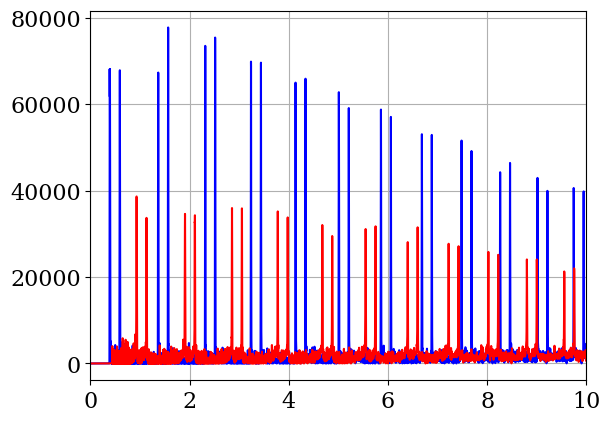

In [338]:
plt.plot( dos0_energies/omB,  dos0_densities, color='blue')
plt.plot( dosIMG_energies/omB,  dosIMG_densities, color='red')


#plt.ylim(0,1e4)

plt.xlim(0,10)

plt.grid()

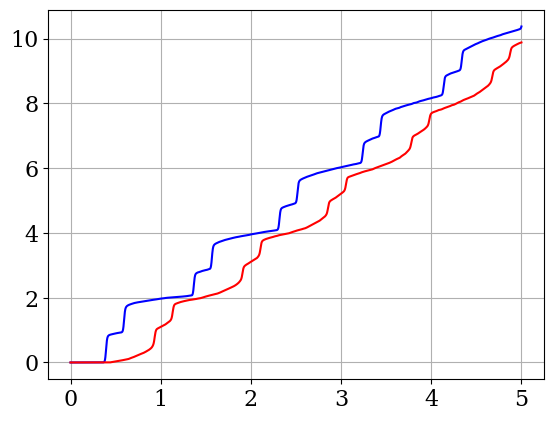

In [339]:
plt.plot( energies_fill/omB, filling0, color='blue')

plt.plot( energies_fill/omB, fillingIMG, color='red')

plt.grid()

In [340]:
fmin = 8
fmax = 4
nimg_min = np.argmin(np.abs(fillingIMG-fmin))
nimg_max = np.argmin(np.abs(fillingIMG-fmax))

n0_min = np.argmin(np.abs(filling0-fmin))
n0_max = np.argmin(np.abs(filling0-fmax))

Ne = 800
energy0 = np.linspace( energies_fill[n0_min], energies_fill[n0_max], Ne)
energyIMG = energy0     #fix same EF for 0 and img

#energyIMG = np.linspace( energies_fill[nimg_min], energies_fill[nimg_max], Ne) #fix same fillings for 0 and img

In [341]:
G0 = np.zeros(Ne)
GIMG = np.zeros(Ne)
for ndis in range(iter_dis):
    Vdis = corr_dis(int(L), int(W), 1, xic)
    
    def G_conductance( E_dis, E_img, L, W, alpha, Vdis, Vimg, ne, energy0, energyIMG  ):
        #energy = ei + (ef-ei)/Ne*ne
        EF0 = energy0[ne]
        EFimg = energyIMG[ne]
        
        #leff = lB* ( energy/ef + .1 )
        #plate_distance = 10*lB**2/leff      #edge-plate distance
        #Vimg0 = v_img_singleside(W, int(W), plate_distance)   # normalized image potential single plate
        #Vimg = Vimg0
        #V_img_min = np.amin(Vimg)
        #Vimg = Vimg - V_img_min - lB/plate_distance**2 
        #E_img = Zeeman*lB * ( (10)**2 )/2. * 2         # Image charge amplitude in Zeeman
        
        
        params =SimpleNamespace( alpha=alpha, E_dis=E_dis, E_img=0, V=Vdis, Vimg=Vimg )
        params_img = SimpleNamespace( alpha=alpha, E_dis=E_dis, E_img=E_img, V=Vdis, Vimg=Vimg )

        smat = kwant.smatrix(sys, energy=EF0, args=[params])
        smat_img = kwant.smatrix(sys, energy=EFimg, args=[params_img])
        G0_ne = smat.transmission(0, 1)
        GIMG_ne = smat_img.transmission(0, 1)
        return G0_ne, GIMG_ne


    # Define a function to compute conductance for a single iteration
    def compute_conductance(ne):
        return G_conductance( E_dis, E_img, L, W, alpha, Vdis, Vimg, ne, energy0, energyIMG  )

    # Use joblib to parallelize the loop
    results = Parallel(n_jobs=Ncore)(
        delayed(compute_conductance)(ne) for ne in range(Ne)
    )

    shotG0 = []
    shotGIMG = []
    # Aggregate the results
    for sG0, sGIMG in results:
        shotG0.append( sG0 )
        shotGIMG.append( sGIMG )

    shotG0 = np.asarray(shotG0)
    shotGIMG = np.asarray(shotGIMG)
    G0 += shotG0/iter_dis
    GIMG += shotGIMG/iter_dis

    

/var/folders/y4/dpq6l9fj2kv9z0prq_6_pyy00000gn/T/ipykernel_1384/1913813268.py:23: KwantDeprecationWarning: The 'args' parameter has been deprecated since version 1.4 -- Instead, provide named parameters as a dictionary via 'params'.
/var/folders/y4/dpq6l9fj2kv9z0prq_6_pyy00000gn/T/ipykernel_1384/1913813268.py:23: KwantDeprecationWarning: The 'args' parameter has been deprecated since version 1.4 -- Instead, provide named parameters as a dictionary via 'params'.
/var/folders/y4/dpq6l9fj2kv9z0prq_6_pyy00000gn/T/ipykernel_1384/1913813268.py:23: KwantDeprecationWarning: The 'args' parameter has been deprecated since version 1.4 -- Instead, provide named parameters as a dictionary via 'params'.
/var/folders/y4/dpq6l9fj2kv9z0prq_6_pyy00000gn/T/ipykernel_1384/1913813268.py:23: KwantDeprecationWarning: The 'args' parameter has been deprecated since version 1.4 -- Instead, provide named parameters as a dictionary via 'params'.
/var/folders/y4/dpq6l9fj2kv9z0prq_6_pyy00000gn/T/ipykernel_1384/1913

In [342]:
from scipy.interpolate import interp1d

filling_interp = interp1d(energies_fill, filling0, kind='cubic', fill_value="extrapolate")
filling0_interp = filling_interp(energy0)


filling_interp = interp1d(energies_fill, fillingIMG, kind='cubic', fill_value="extrapolate")
fillingIMG_interp = filling_interp(energyIMG)


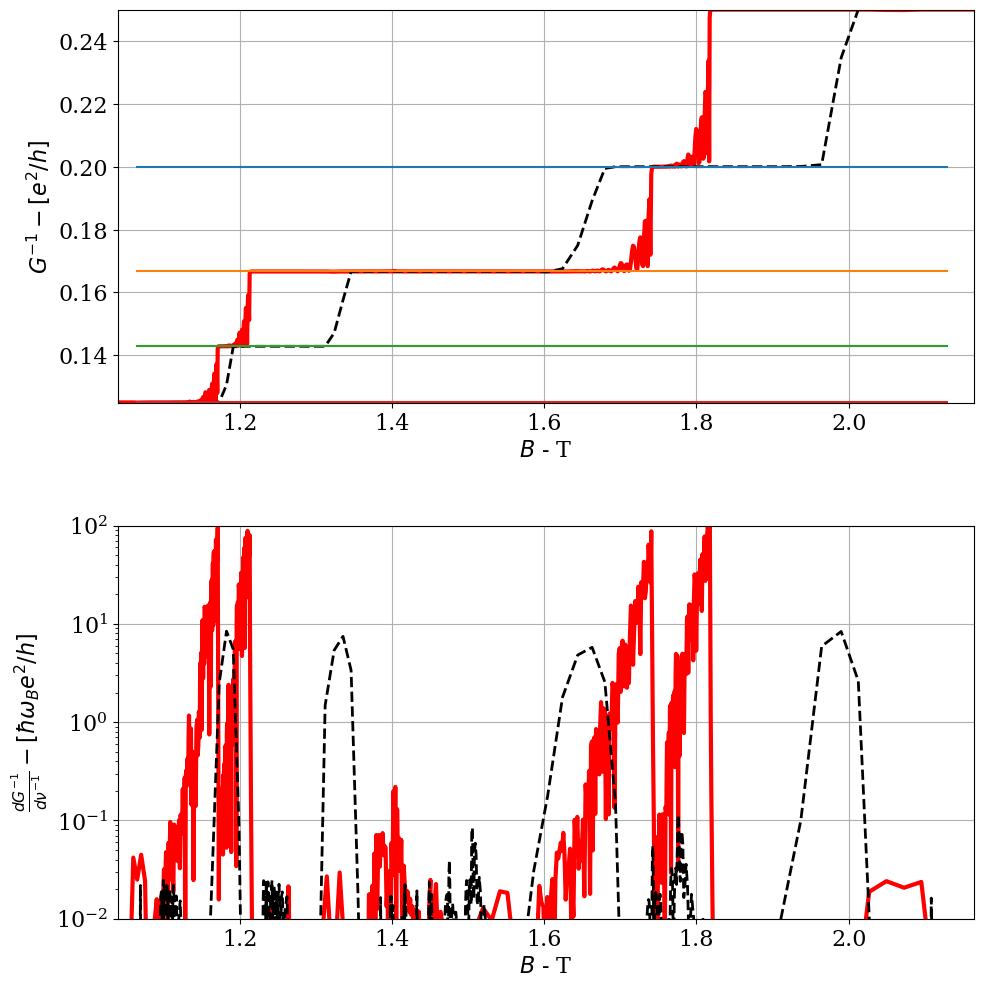

In [343]:
from scipy.ndimage import gaussian_filter
#G0T1 = G0*0     + finite_temp(T, G0, energies)
#GIMGT =  GIMG*0   +finite_temp(T, GIMG, energies)
G0T = gaussian_filter(G0, sigma=.25)
GIMGT = gaussian_filter(GIMG, sigma=.25)


dG0_dnu = np.gradient(1/G0T, 1/filling0_interp)
dGIMG_dnu = np.gradient(1/GIMGT, 1/fillingIMG_interp)

Ne_0 = 100
Ne_img = 85
# \pi \hbar/e = 2x10^-15 m^2 T ==> 2x10^3 nm^2 T
# B_gauge = \hbar/(e l0^2) with l0 \sim 0.1-1 nm => B_gauge = 10^3-10^4 T
B_gauge = 1e3
effB0 = Ne_0/( filling0_interp*(W-1)*(L-1) )*B_gauge
effBimg = Ne_img/( fillingIMG_interp*(W-1)*(L-1) )*B_gauge


Gamma_img = 2*E_img/lB / ( (plate_distance/lB)**2 + 0*2*plate_distance/lB )
#print plateous
# Font configuration
font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 16,
}
# Apply the font globally
plt.rcParams['font.family'] = font['family']
plt.rcParams['font.size'] = font['size']
plt.rcParams['axes.labelsize'] = font['size']
plt.rcParams['xtick.labelsize'] = font['size']
plt.rcParams['ytick.labelsize'] = font['size']

# Create the figure and subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))
# First subplot
ax1.plot( effBimg, 1/GIMGT, color='red', linestyle='-', linewidth=3)
ax1.plot( effB0, 1/G0T, color='black', linestyle='--', linewidth=2)

ax1.plot(effB0, 1/5*np.ones(len(filling0_interp)))
ax1.plot(effB0, 1/6*np.ones(len(filling0_interp)))
ax1.plot(effB0, 1/7*np.ones(len(filling0_interp)))
ax1.plot(effB0, 1/8*np.ones(len(filling0_interp)))

ax1.set_ylabel(r"$G^{-1} - [e^2/h]$", fontdict=font)

ax2.plot( effBimg, np.abs(dGIMG_dnu), color='red', linestyle='-', linewidth=3)
ax2.plot( effB0, np.abs(dG0_dnu), color='black', linestyle='--', linewidth=2)


ax2.set_ylabel(r"$\frac{dG^{-1}}{d\nu^{-1}} - [\hbar \omega_Be^2/h]$", fontdict=font)
ax2.set_xlabel(r"$B$ - T", fontdict=font)

x1 = min(np.amin(effBimg), np.amin(effB0))
x2 = max(np.amax(effBimg), np.amax(effB0))

y1 = min(np.amin(1/GIMGT), np.amin(1/G0T))
y2 = max(np.amax(1/GIMGT), np.amax(1/G0T))

ax1.set_ylim((y1, y2))
ax1.set_xlim((x1, x2))
ax1.set_xlabel(r"$B$ - T", fontdict=font)
#ax1.set_yticks(np.arange(0, 2, 1)) 


ax2.set_ylim((1e-2, 1e2))  # Adjust the lower limit to avoid log(0) issues
ax2.set_xlim((x1, x2))

ax2.set_yscale('log')  # Set log scale on y-axis

ax1.grid()
ax2.grid()
#ax1.set_xticklabels([])



plt.tight_layout()
plt.gcf().set_size_inches(270 / 25.4, 270 / 25.4)

plt.show()

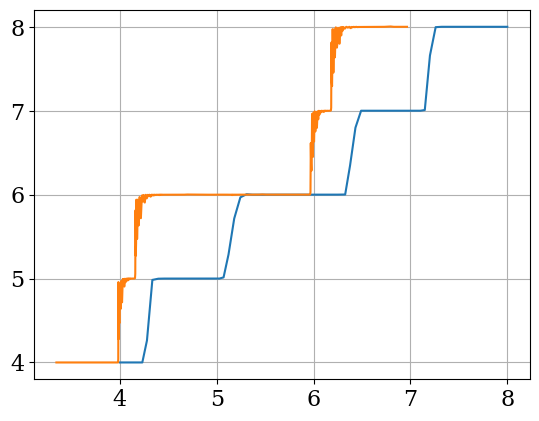

In [344]:
plt.plot(filling0_interp, G0T)
plt.plot(fillingIMG_interp, GIMGT)
plt.grid()

In [345]:
# save platos in a file
import pandas as pd
nG = 0
# Parameters
params = {
    "t": t,
    "W": W,
    "L": L,
    "alpha": alpha,
    "xic": xic,
    "plate_distance": plate_distance,
    "E_dis": E_dis,
    "E_img": E_img,
    "ei": ei,
    "ef": ef,
    "Ne": Ne,
    "iter_dis": iter_dis,
    "Ncore": Ncore
}

# Create a DataFrame
data = pd.DataFrame({
    'Energies0': energy0,
    'EnergiesIMG': energyIMG,
    'G0': G0,
    'GIMG': GIMG
})

# Write parameters and data to a file
filename = 'G_%d.dat' % (nG)
with open(filename, 'w') as f:
    # Write parameters as comments
    for key, value in params.items():
        f.write(f"# {key} = {value}\n")
    # Write the data
    data.to_csv(f, sep=' ', index=False, header=True)

In [346]:
# save platos in a file
import pandas as pd
nG = 0
# Parameters
params = {
    "t": t,
    "W": W,
    "L": L,
    "alpha": alpha,
    "xic": xic,
    "plate_distance": plate_distance,
    "E_dis": E_dis,
    "E_img": E_img,
    "ei": ei,
    "ef": ef,
    "Ne": Ne,
    "iter_dis": iter_dis,
    "Ncore": Ncore,
    "T": T
}

# Create a DataFrame
data = pd.DataFrame({
    'Energies': energy0,
    'filling0': filling0_interp,
    'fillingIMG': fillingIMG_interp
})

# Write parameters and data to a file
filename = 'filling_%d.dat' % (nG)
with open(filename, 'w') as f:
    # Write parameters as comments
    for key, value in params.items():
        f.write(f"# {key} = {value}\n")
    # Write the data
    data.to_csv(f, sep=' ', index=False, header=True)